In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

from src.constants import (
    TARGET_COL,
    MULTILABEL_COLS,
    CATEGORICAL_COLS,
    CLASS_LABELS,
    RANDOM_STATE,
    CV_SPLITS,
    PROCESSED_DATA_PATH,
)
from src.preprocessing import load_processed_dataset, temporal_train_val_test_split
from src.encoders import fit_mlb_encoder, fit_ohe_encoder, build_mlb_ohe_matrix
from src.evaluation import (
    evaluate_classification_model,
    fit_random_forest_classifier,
    compare_results_table,
)
from src.visualisations import plot_feature_importance, get_original_feature

In [2]:
# Load preprocessed dataset and apply the temporal train/val/test split
df = load_processed_dataset(PROCESSED_DATA_PATH)
df_train, df_val, df_test = temporal_train_val_test_split(df)
df_train = pd.concat([df_train, df_val], ignore_index=True)

print(f"Training rows : {len(df_train)}")
print(f"Test rows : {len(df_test)}")
print(f"\nClass distribution (train):")
print(df_train[TARGET_COL].value_counts())
print(f"\nClass distribution (test):")
print(df_test[TARGET_COL].value_counts())

Training rows : 7312
Test rows : 1938

Class distribution (train):
decision_taken
Informal Action Taken    5834
No Further Action         910
Investigation Pursued     568
Name: count, dtype: int64

Class distribution (test):
decision_taken
Informal Action Taken    1836
No Further Action          72
Investigation Pursued      30
Name: count, dtype: int64


In [3]:
# Fit encoders on training data only
mlb_encoder = fit_mlb_encoder(df_train, MULTILABEL_COLS)
ohe_encoder = fit_ohe_encoder(df_train, CATEGORICAL_COLS)

for col, encoder in mlb_encoder.items():
    print(f"{col}: {len(encoder.classes_)} unique labels")
for col in CATEGORICAL_COLS:
    print(f"{col}: {df_train[col].nunique()} unique values")

data_subject_type: 9 unique labels
data_type: 16 unique labels
incident_category: 2 unique values
incident_type: 21 unique values
no_data_subjects_affected: 7 unique values
time_taken_to_report: 4 unique values


In [4]:
# Build MLB + OHE feature matrices for Random Forest
X_train_ohe = build_mlb_ohe_matrix(df_train, mlb_encoder, ohe_encoder)
X_test_ohe = build_mlb_ohe_matrix(df_test, mlb_encoder, ohe_encoder)

y_train = df_train[TARGET_COL].reset_index(drop=True)
y_test = df_test[TARGET_COL].reset_index(drop=True)

print(f"X_train_ohe shape: {X_train_ohe.shape}")
print(f"X_test_ohe shape: {X_test_ohe.shape}")
print(f"\nHead of X_train_ohe:\n {X_train_ohe.head(3).to_string()}")

assert X_train_ohe.isnull().sum().sum() == 0, "Null values found in X_train_ohe"
assert X_test_ohe.isnull().sum().sum() == 0, "Null values found in X_test_ohe"
print("No nulls in feature matrices")

X_train_ohe shape: (7312, 59)
X_test_ohe shape: (1938, 59)

Head of X_train_ohe:
    incident_category_Cyber  incident_category_Non Cyber  incident_type_Alteration of personal data  incident_type_Brute Force  incident_type_Data emailed to incorrect recipient  incident_type_Data of wrong data subject shown in client portal  incident_type_Data posted or faxed to incorrect recipient  incident_type_Denial of service  incident_type_Failure to redact  incident_type_Failure to use bcc  incident_type_Hardware/software misconfiguration  incident_type_Incorrect disposal of hardware  incident_type_Incorrect disposal of paperwork  incident_type_Loss/theft of device containing personal data  incident_type_Loss/theft of paperwork or data left in insecure location  incident_type_Malware  incident_type_Not Provided  incident_type_Other cyber incident  incident_type_Other non-cyber incident  incident_type_Phishing  incident_type_Ransomware  incident_type_Unauthorised access  incident_type_Verbal disclo

Evaluating RF MLB+OHE (Balanced)


Classification Report:
                       precision    recall  f1-score   support

Informal Action Taken       0.96      0.83      0.89      1836
Investigation Pursued       0.02      0.10      0.03        30
    No Further Action       0.15      0.33      0.21        72

             accuracy                           0.80      1938
            macro avg       0.38      0.42      0.38      1938
         weighted avg       0.92      0.80      0.85      1938

Accuracy: 0.8013
Macro F1 Score: 0.3764
Macro Precision: 0.3773
Macro Recall: 0.4215
Macro ROC AUC: 0.6713
Macro PR AUC: 0.3796
Log Loss: 0.6569

Per-Class F1 Scores:
	Informal Action Taken: F1 Score: 0.8921, ROC AUC: 0.6807
	Investigation Pursued: F1 Score: 0.0264, ROC AUC: 0.5668
	No Further Action: F1 Score: 0.2105, ROC AUC: 0.7664


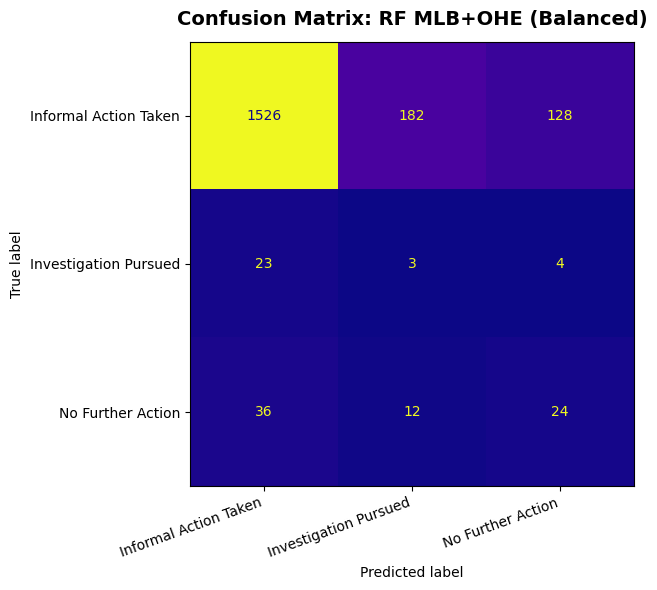

Confusion Matrix table:

                       Informal Action Taken  Investigation Pursued  \
Informal Action Taken                   1526                    182   
Investigation Pursued                     23                      3   
No Further Action                         36                     12   

                       No Further Action  
Informal Action Taken                128  
Investigation Pursued                  4  
No Further Action                     24  
Evaluating RF MLB+OHE (No Weights)


Classification Report:
                       precision    recall  f1-score   support

Informal Action Taken       0.96      0.96      0.96      1836
Investigation Pursued       0.07      0.10      0.08        30
    No Further Action       0.28      0.28      0.28        72

             accuracy                           0.92      1938
            macro avg       0.44      0.44      0.44      1938
         weighted avg       0.92      0.92      0.92      1938

Accuracy: 0.91

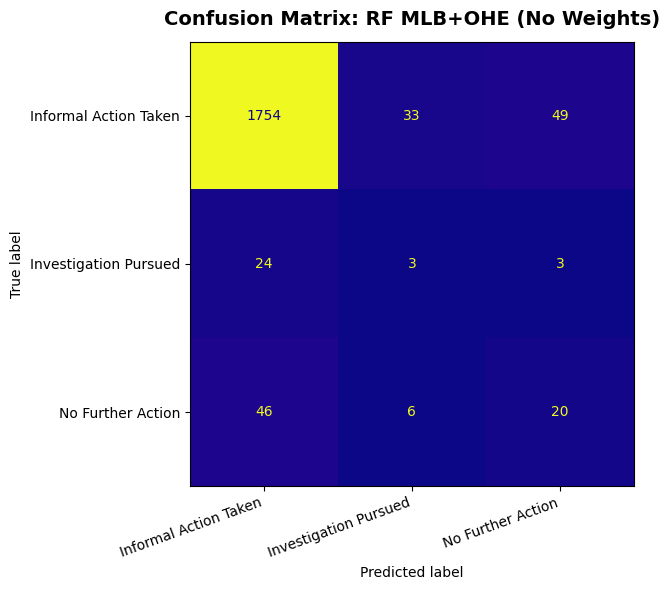

Confusion Matrix table:

                       Informal Action Taken  Investigation Pursued  \
Informal Action Taken                   1754                     33   
Investigation Pursued                     24                      3   
No Further Action                         46                      6   

                       No Further Action  
Informal Action Taken                 49  
Investigation Pursued                  3  
No Further Action                     20  


In [5]:
rf_results = {}
rf_models  = {}

rf_models["baseline"], rf_results["baseline"] = fit_random_forest_classifier(
    "RF MLB+OHE (Balanced)",
    X_train_ohe,
    y_train,
    X_test_ohe,
    y_test,
    class_weights="balanced"
)

rf_models["none"], rf_results["none"] = fit_random_forest_classifier(
    "RF MLB+OHE (No Weights)",
    X_train_ohe,
    y_train,
    X_test_ohe,
    y_test,
    class_weights=None
)

In [6]:
rf_comparison = compare_results_table([rf_results["baseline"],rf_results["none"]])

Metric Headings:
                  model  accuracy  macro_f1  macro_precision  macro_recall  macro_roc_auc  macro_pr_auc  log_loss
  RF MLB+OHE (Balanced)  0.801342  0.376365         0.377284      0.421496       0.671291      0.379629  0.656946
RF MLB+OHE (No Weights)  0.916925  0.439860         0.436943      0.444372       0.715936      0.404021  0.491391
Ranked by macro F1 Score:
                  model  accuracy  macro_f1  macro_precision  macro_recall  macro_roc_auc  macro_pr_auc  log_loss
RF MLB+OHE (No Weights)  0.916925  0.439860         0.436943      0.444372       0.715936      0.404021  0.491391
  RF MLB+OHE (Balanced)  0.801342  0.376365         0.377284      0.421496       0.671291      0.379629  0.656946
Ranked by macro ROC-AUC:
                  model  accuracy  macro_f1  macro_precision  macro_recall  macro_roc_auc  macro_pr_auc  log_loss
RF MLB+OHE (No Weights)  0.916925  0.439860         0.436943      0.444372       0.715936      0.404021  0.491391
  RF MLB+OHE (Balanc

In [7]:
tscv = TimeSeriesSplit(n_splits=CV_SPLITS)

param_grid = {
    "n_estimators": [50, 100, 300, 500, 700, 1000],
    "max_features": ["sqrt", "log2", 0.5],
    "min_samples_leaf": [1, 3, 5]
}

print("RF GridSearchCV grid:")
total_combinations = 1
for key, values in param_grid.items():
    print(f"\t{key}: {values}")
    total_combinations *= len(values)
print(f"Total combinations: {total_combinations} ({total_combinations * CV_SPLITS} fits with {CV_SPLITS}-fold CV)")

rf_tune = RandomForestClassifier(
    max_depth=None,
    class_weight=None,
    n_jobs=1,
    random_state=RANDOM_STATE,
)

rf_grid = GridSearchCV(
    estimator=rf_tune,
    param_grid=param_grid,
    cv=tscv,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=False,
    refit=True,
)

rf_grid.fit(X_train_ohe, y_train)

RF GridSearchCV grid:
	n_estimators: [50, 100, 300, 500, 700, 1000]
	max_features: ['sqrt', 'log2', 0.5]
	min_samples_leaf: [1, 3, 5]
Total combinations: 54 (270 fits with 5-fold CV)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 3, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fo

In [8]:
print("\nBest parameters found:")
for key, value in rf_grid.best_params_.items():
    print(f"\t{key}: {value}")
print(f"Best CV macro F1: {rf_grid.best_score_:.4f}")

# Top 5 combinations for the writeup
rf_cv = pd.DataFrame(rf_grid.cv_results_)
print("\nTop 5 parameter combinations by CV macro F1:")
print(rf_cv[["params", "mean_test_score", "std_test_score"]].sort_values("mean_test_score", ascending=False).head(5).to_string(index=False))


Best parameters found:
	max_features: sqrt
	min_samples_leaf: 1
	n_estimators: 50
Best CV macro F1: 0.4536

Top 5 parameter combinations by CV macro F1:
                                                              params  mean_test_score  std_test_score
 {'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 50}         0.453574        0.051254
{'max_features': 'log2', 'min_samples_leaf': 1, 'n_estimators': 100}         0.452359        0.046801
   {'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 100}         0.447510        0.035884
{'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 100}         0.446347        0.039861
{'max_features': 'log2', 'min_samples_leaf': 1, 'n_estimators': 500}         0.444738        0.039201


Evaluating RF MLB+OHE — No Weights (TUNED)


Classification Report:
                       precision    recall  f1-score   support

Informal Action Taken       0.96      0.96      0.96      1836
Investigation Pursued       0.06      0.07      0.06        30
    No Further Action       0.30      0.31      0.30        72

             accuracy                           0.92      1938
            macro avg       0.44      0.44      0.44      1938
         weighted avg       0.92      0.92      0.92      1938

Accuracy: 0.9190
Macro F1 Score: 0.4410
Macro Precision: 0.4392
Macro Recall: 0.4431
Macro ROC AUC: 0.7092
Macro PR AUC: 0.3998
Log Loss: 0.5395

Per-Class F1 Scores:
	Informal Action Taken: F1 Score: 0.9588, ROC AUC: 0.7353
	Investigation Pursued: F1 Score: 0.0606, ROC AUC: 0.5899
	No Further Action: F1 Score: 0.3034, ROC AUC: 0.8025


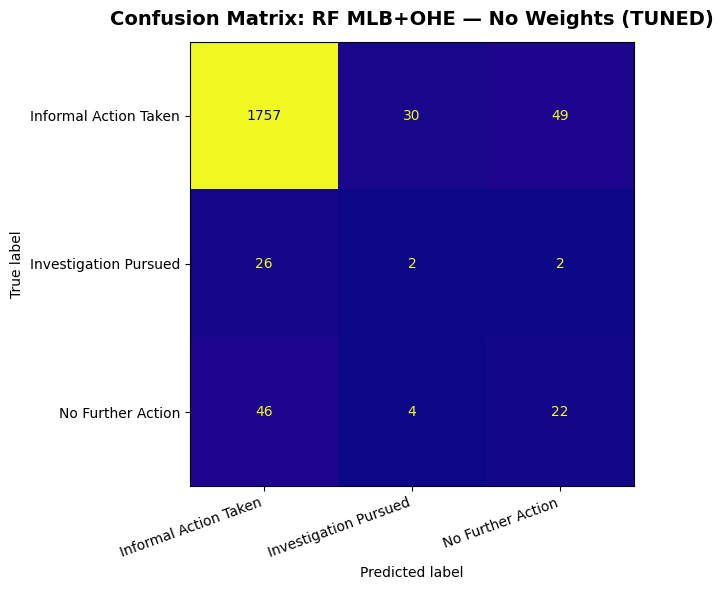

Confusion Matrix table:

                       Informal Action Taken  Investigation Pursued  \
Informal Action Taken                   1757                     30   
Investigation Pursued                     26                      2   
No Further Action                         46                      4   

                       No Further Action  
Informal Action Taken                 49  
Investigation Pursued                  2  
No Further Action                     22  


In [9]:
final_tuned_model = rf_grid.best_estimator_
rf_tuned_results = evaluate_classification_model(
    "RF MLB+OHE — No Weights (TUNED)",
    final_tuned_model, X_test_ohe, y_test,
)   



 Original feature mapping:
                                                        feature
                                        incident_category_Cyber
                                    incident_category_Non Cyber
                      incident_type_Alteration of personal data
                                      incident_type_Brute Force
              incident_type_Data emailed to incorrect recipient
incident_type_Data of wrong data subject shown in client portal
      incident_type_Data posted or faxed to incorrect recipient
                                incident_type_Denial of service
                                incident_type_Failure to redact
                               incident_type_Failure to use bcc
Feature importance (grouped by original feature):
original_feature
incident_type                0.224590
data_subject_type            0.188192
data_type                    0.179367
no_data_subjects_affected    0.155936
incident_category            0.130494
time_taken_

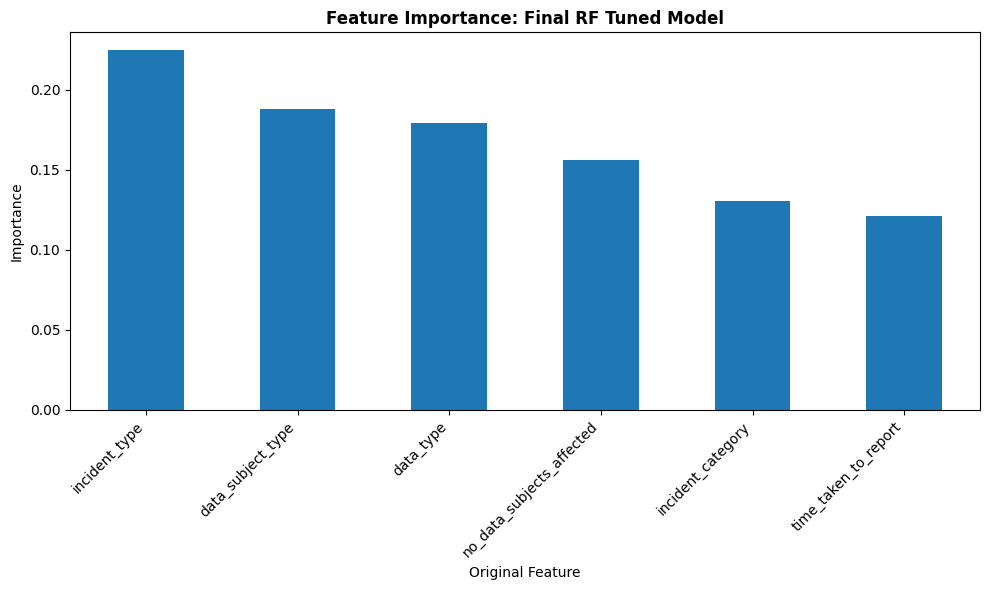

,feature,importance,original_feature
0,incident_category_Cyber,0.049751,incident_category
1,incident_category_Non Cyber,0.080744,incident_category
2,incident_type_Alteration of personal data,0.002646,incident_type
3,incident_type_Brute Force,0.002088,incident_type
4,incident_type_Data emailed to incorrect recipient,0.013985,incident_type
5,incident_type_Data of wrong data subject shown...,0.003801,incident_type
6,incident_type_Data posted or faxed to incorrec...,0.007311,incident_type
7,incident_type_Denial of service,0.001311,incident_type
8,incident_type_Failure to redact,0.006545,incident_type
9,incident_type_Failure to use bcc,0.003232,incident_type


In [10]:
rf_importances = final_tuned_model.feature_importances_

importance_df = pd.DataFrame({
    "feature": X_train_ohe.columns,
    "importance": rf_importances,
})

print("\n Original feature mapping:")
print(importance_df[["feature"]].head(10).to_string(index=False))

importance_df["original_feature"] = importance_df["feature"].apply(lambda c: get_original_feature(c, CATEGORICAL_COLS))
importance_grouped = importance_df.groupby("original_feature")["importance"].sum().sort_values(ascending=False)

print("Feature importance (grouped by original feature):")
print(importance_grouped.to_string())

print("\nTop 15 raw features (including individual encoded sub-columns):")
print(importance_df.sort_values("importance", ascending=False).head(15).to_string(index=False))

plot_feature_importance(
    rf_importances,
    list(X_train_ohe.columns),
    title="Feature Importance: Final RF Tuned Model",
    categorical_cols=CATEGORICAL_COLS,
    group_by_original_feature=True,
)